# More Exploring with KDE 

Some Notes:
Without weighting, epsilon is just a Euclidean threshold, so it triggers simplex births earlier in dense regions and later in sparse ones. With weighting, epsilon becomes a density-corrected threshold that should trigger births at roughly the same rate everywhere, regardless of local sampling density.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sample_circle_half_dense(n, p_dense=0.8, seed=None):
    """
    Sample n points on the unit circle, with p_dense fraction in the dense
    half (theta in [0, pi)) and the remainder in the sparse half ([pi, 2pi)).
    """
    rng = np.random.default_rng(seed)

    # Choose which half each point comes from
    dense_mask = rng.random(n) < p_dense

    theta = np.empty(n)

    # Dense half: [0, pi)
    theta[dense_mask] = rng.uniform(0.0, np.pi, dense_mask.sum())

    # Sparse half: [pi, 2pi)
    theta[~dense_mask] = rng.uniform(np.pi, 2 * np.pi, (~dense_mask).sum())

    X = np.column_stack([np.cos(theta), np.sin(theta)])
    return X, theta

def plot_circle_points(X):
    """Plot 2D points sampled on the unit circle."""
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], s=10)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Half-Dense Circle")
    plt.show()


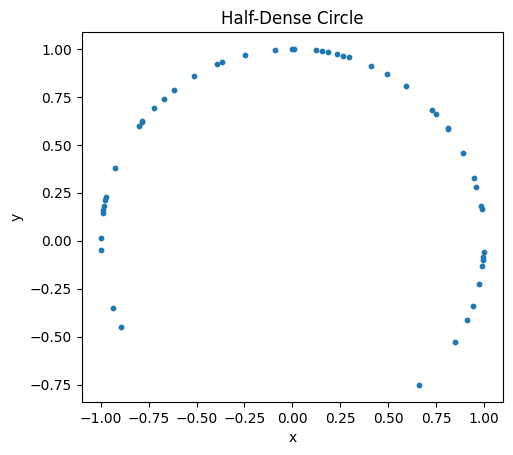

Unweighted max distance: 2.0000
Weighted max distance: 2.6922
Epsilon unweighted: 0.3000
Epsilon weighted (scaled): 0.4038


In [9]:
import ecc_vr as vr

X, theta = sample_circle_half_dense(50, p_dense=0.8, seed=0)
plot_circle_points(X)

# Compute weighted distance matrix
Dw, _ = vr.weighted_distance_matrix_kde(X, h=0.15, d_manifold=1, sym_rule="min")
D = vr.pairwise_dist(X)

# Define base epsilon (in unweighted distance units)
eps_base = 0.3

# Scale epsilon by ratio of max distances to maintain comparable probe size
eps_scaled = eps_base * (Dw.max() / D.max())

print(f"Unweighted max distance: {D.max():.4f}")
print(f"Weighted max distance: {Dw.max():.4f}")
print(f"Epsilon unweighted: {eps_base:.4f}")
print(f"Epsilon weighted (scaled): {eps_scaled:.4f}")




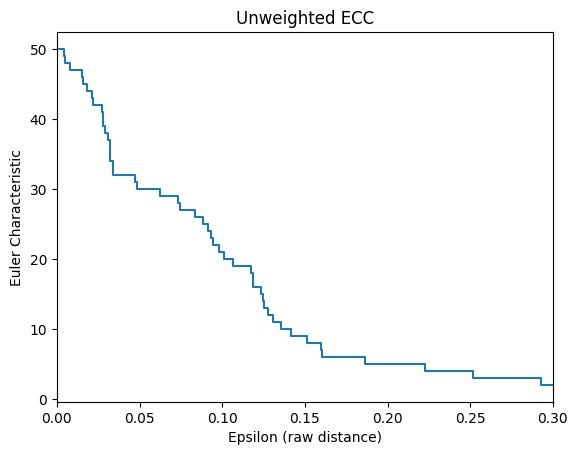

In [10]:
C_raw = vr.local_contributions(X, epsilon=eps_base, max_dim=None)
vr.plot_ECC_from_C(C_raw, eps_min=0.0, eps_max=eps_base, num=300, title="Unweighted ECC", xlabel="Epsilon (raw distance)")

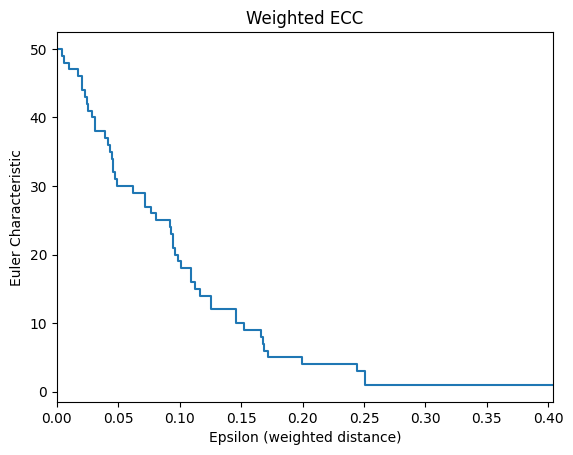

In [11]:
Cw = vr.local_contributions(X, epsilon=eps_scaled, max_dim=None, D=Dw)
vr.plot_ECC_from_C(Cw, eps_min=0.0, eps_max=eps_scaled, num=300, title="Weighted ECC", xlabel="Epsilon (weighted distance)")

# Interpretation

In order to do a side by side comparison of unweighted to weighted ECC we scaled the epsilon by the ratio of the max distances in the weighted vs unweighted matrices. Yeilding:

Unweighted max distance: $2.000$

Weighted max distance: $2.692$

Epsilon unweighted: $0.300$

Epsilon weighted (scaled): $0.403$

Thus giving us 

Unweighted: $0.300 / 2.000 = 15\%$ of max distance

Weighted: $0.403 / 2.692 = 14.96 \approx 15\%$ of max distance 

Since the weighted max distance is larger it means that the KDE weighting is expanding the overall distance scale. So, the weighted metric's distances are spread out (max = 2.692) and
to reach the same relative distance fraction, we need a larger epsilon value. Once scaled, both reveal identical topology. However, the weighted graph does hit the natural Euler Characteristic of the circle faster than the unweighted, which was our goal!

# Now we wish to compare using a KDE to the real pdf


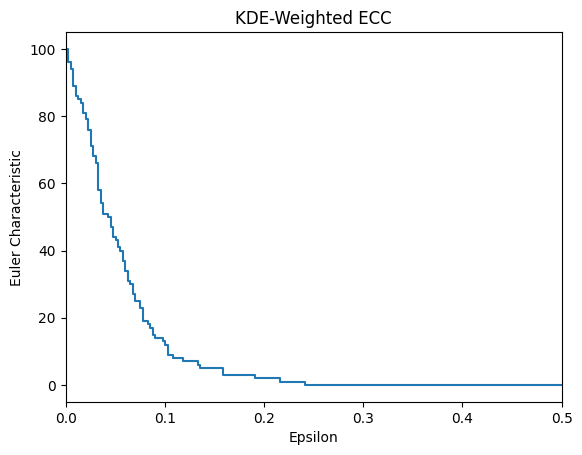

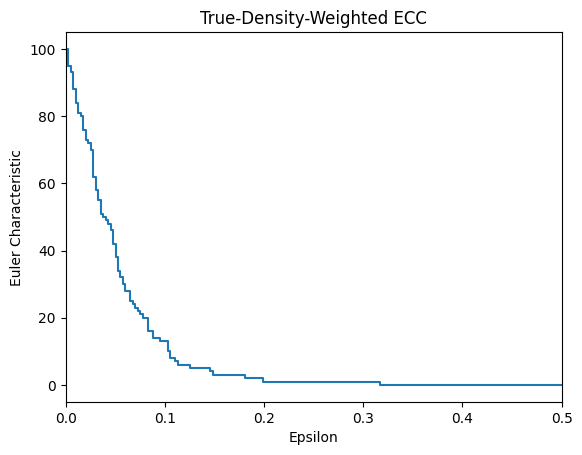

In [12]:
def true_density_half_dense(theta: np.ndarray, p_dense: float = 0.8) -> np.ndarray:
    """
    True PDF of sample_circle_half_dense evaluated at each angle theta.
    Dense half [0, pi):   p_dense / pi
    Sparse half [pi, 2pi): (1 - p_dense) / pi
    """
    f = np.where(theta < np.pi, p_dense / np.pi, (1 - p_dense) / np.pi)
    return f


def weighted_distance_matrix_f(X, f, d_manifold=1, sym_rule="min"):
    """
    Like weighted_distance_matrix, but accepts a precomputed density array f
    instead of estimating it via KDE. f is mean-normalized internally.
    """
    X = np.asarray(X, dtype=float)
    D = vr.pairwise_dist(X)

    f = np.maximum(f, 1e-12)
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w


# comparison
p_dense = 0.8
X, theta = sample_circle_half_dense(100, p_dense=p_dense, seed=0)

# KDE-weighted
Dw_kde, _ = vr.weighted_distance_matrix_kde(X, h=0.15, d_manifold=1, sym_rule="min")

# True-density-weighted
f_true = true_density_half_dense(theta, p_dense=p_dense)
Dw_true = weighted_distance_matrix_f(X, f_true, d_manifold=1, sym_rule="min")

eps = 0.5

C_kde  = vr.local_contributions(X, epsilon=eps, max_dim=None, D=Dw_kde)
C_true = vr.local_contributions(X, epsilon=eps, max_dim=None, D=Dw_true)

vr.plot_ECC_from_C(C_kde,  eps_min=0.0, eps_max=eps, num=200, title="KDE-Weighted ECC", xlabel= "Epsilon")
vr.plot_ECC_from_C(C_true, eps_min=0.0, eps_max=eps, num=200, title="True-Density-Weighted ECC", xlabel= "Epsilon")

In [45]:
import numpy as np
import ecc_vr as vr

rng = np.random.default_rng(42)
X = rng.uniform(0, 2*np.pi, size=(10, 1))

Y, theta = sample_circle_half_dense(1, p_dense=0.5, seed=0)

f = vr.fhat(X, h = 1.5, d_manifold = 1)
print(f)

fy = vr.fhat(Y, h = 5, d_manifold=1)
#print(fy)
#print(sum(fy))





[0.17026249 0.12639584 0.15843614 0.17001737 0.07371777 0.12401636
 0.1709248  0.16936356 0.0789336  0.12860689]
